# Wykres podprzestrzeni DMRG + interesujące połączenie

Notebook rysuje:

- **pomarańczową podprzestrzeń DMRG** od `s1` do `s2`,
- **pomarańczową ścieżkę DMRG/MPS** jak wcześniej,
- **czerwony obszar interesującego połączenia** między `s1` i `s2`:
  dwa czerwone okręgi, dwie styczne linie łączące ich brzegi oraz czerwone wypełnienie wewnątrz.

Najważniejsze wywołanie:

```python
plot_current_lattice_subspace_with_connection(13, 20, plot_type="truesnake")
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.patches import Polygon, Circle

# ============================================================
#  Konfiguracja układu
# ============================================================
Nx = 5
Ny = 4
yperiodic = "false"


In [2]:
# ============================================================
#  Pomocnicze funkcje geometrii honeycomb
# ============================================================
def as_bool(x):
    if isinstance(x, str):
        return x.lower() == "true"
    return bool(x)


def shorten_segment(p1, p2, frac=0.22):
    p1 = np.array(p1, float)
    p2 = np.array(p2, float)
    d = p2 - p1
    return p1 + frac * d, p2 - frac * d


def max_scatter_s_no_overlap(ax, pos_xy, safety=0.85):
    """Dobiera rozmiar markerów tak, żeby site'y się nie nakładały."""
    disp = ax.transData.transform(pos_xy)

    dmin2 = np.inf
    for i in range(len(disp)):
        di = disp[i] - disp
        dist2 = di[:, 0]**2 + di[:, 1]**2
        dist2[i] = np.inf
        dmin2 = min(dmin2, dist2.min())

    dmin_px = np.sqrt(dmin2)
    diameter_px = dmin_px * safety
    radius_px = diameter_px / 2.0

    dpi = ax.figure.dpi
    radius_pt = radius_px * 72.0 / dpi

    return np.pi * radius_pt**2


def site_radius_from_geometry(pos, scale=0.33):
    """Promień w jednostkach geometrii sieci."""
    dmin = np.inf

    for i in range(len(pos)):
        d = pos[i] - pos
        dist = np.sqrt(d[:, 0]**2 + d[:, 1]**2)
        dist[i] = np.inf
        dmin = min(dmin, dist.min())

    return scale * dmin


def bonds_pila(Nx, Ny, yperiodic=False):
    """Klasyczna numeracja typu piła / bottom-up."""
    Nsites = 2 * Nx * Ny
    bonds = []

    for i in range(1, Nsites):
        if i % 2 == 1:
            bonds.append((i, i + 1, "xx"))
        else:
            if i <= 2 * Ny * (Nx - 1):
                bonds.append((i, i + 2 * Ny - 1, "yy"))

            if i % (2 * Ny) != 0:
                bonds.append((i, i + 1, "zz"))
            elif yperiodic:
                col_start = i - 2 * Ny + 1
                bonds.append((i, col_start, "zz"))

    return Nsites, bonds


def site_index_snake_vertical(x, y, sub, Nx, Ny):
    """Semi-snake po kolumnach."""
    col_offset = 2 * Ny * (x - 1)
    yeff = y if x % 2 == 1 else Ny - y + 1
    return col_offset + 2 * (yeff - 1) + sub


def site_index_true_snake_vertical(x, y, sub, Nx, Ny):
    """True-snake po kolumnach: na parzystych kolumnach odwraca się też kolejność A/B."""
    col_offset = 2 * Ny * (x - 1)

    if x % 2 == 1:
        yeff = y
        subeff = sub
    else:
        yeff = Ny - y + 1
        subeff = 3 - sub

    return col_offset + 2 * (yeff - 1) + subeff


def bonds_from_indexer(Nx, Ny, yperiodic=False, indexer=site_index_snake_vertical):
    Nsites = 2 * Nx * Ny
    bonds = []

    def A(x, y):
        return indexer(x, y, 1, Nx, Ny)

    def B(x, y):
        return indexer(x, y, 2, Nx, Ny)

    for x in range(1, Nx + 1):
        for y in range(1, Ny + 1):
            bonds.append((A(x, y), B(x, y), "xx"))

            if y < Ny:
                bonds.append((B(x, y), A(x, y + 1), "zz"))
            elif yperiodic:
                bonds.append((B(x, y), A(x, 1), "zz"))

            if x < Nx:
                bonds.append((B(x, y), A(x + 1, y), "yy"))

    return Nsites, bonds


def bonds_snake(Nx, Ny, yperiodic=False):
    return bonds_from_indexer(
        Nx, Ny,
        yperiodic=yperiodic,
        indexer=site_index_snake_vertical,
    )


def bonds_truesnake(Nx, Ny, yperiodic=False):
    return bonds_from_indexer(
        Nx, Ny,
        yperiodic=yperiodic,
        indexer=site_index_true_snake_vertical,
    )


def bonds_snake_rows(Nx, Ny, yperiodic=False):
    """Snake po wierszach, zgodny z blokami długości 2*Nx."""
    Nsites = 2 * Nx * Ny
    bonds = []

    for i in range(1, Nsites):
        if i % 2 != 0:
            bonds.append((i, i + 1, "xx"))
        else:
            if i % (2 * Nx) != 0:
                bonds.append((i, i + 1, "yy"))

            if i <= 2 * Nx * (Ny - 1):
                bonds.append((i, i + 2 * Nx - 1, "zz"))
            elif yperiodic:
                bonds.append((i, i - 2 * Nx * (Ny - 1) + 1, "zz"))

    return Nsites, bonds


def get_bonds(Nx, Ny, plot_type="truesnake", yperiodic=False):
    plot_type = plot_type.lower()

    if plot_type in ["pila", "piła", "bottom", "bottomup", "bottom-up", "saw"]:
        return bonds_pila(Nx, Ny, yperiodic=yperiodic)

    if plot_type in ["snake", "semisnake", "semi-snake"]:
        return bonds_snake(Nx, Ny, yperiodic=yperiodic)

    if plot_type in ["truesnake", "true_snake", "true-snake"]:
        return bonds_truesnake(Nx, Ny, yperiodic=yperiodic)

    if plot_type in ["snake_rows", "rows", "horizontal", "row-snake"]:
        return bonds_snake_rows(Nx, Ny, yperiodic=yperiodic)

    raise ValueError(
        "Nieznany plot_type. Dostępne: "
        "'pila', 'snake', 'truesnake', 'snake_rows'."
    )


def honeycomb_positions_from_bonds(Nx, Ny, bonds):
    Nsites = 2 * Nx * Ny

    a = 1.0
    vx = (np.sqrt(3) * a,  a)
    vy = (np.sqrt(3) * a, -a)
    vz = (0.0,          2 * a)

    vmap = {
        "xx": vx,
        "yy": vy,
        "zz": vz,
    }

    adj = [[] for _ in range(Nsites + 1)]

    for s1, s2, bt in bonds:
        v = vmap[bt]
        adj[s1].append((s2, v))
        adj[s2].append((s1, (-v[0], -v[1])))

    pos = np.zeros((Nsites + 1, 2), dtype=float)
    placed = np.zeros(Nsites + 1, dtype=bool)

    pos[1] = (0.0, 0.0)
    placed[1] = True
    queue = [1]

    while queue:
        s = queue.pop(0)
        xs, ys = pos[s]

        for t, v in adj[s]:
            if not placed[t]:
                pos[t] = (xs + v[0], ys + v[1])
                placed[t] = True
                queue.append(t)

    return pos[1:]


def get_lattice_geometry(Nx, Ny, plot_type="truesnake", yperiodic=False):
    _, bonds = get_bonds(Nx, Ny, plot_type=plot_type, yperiodic=yperiodic)
    pos = honeycomb_positions_from_bonds(Nx, Ny, bonds)
    return bonds, pos


In [10]:
# ============================================================
#  Wykres podprzestrzeni DMRG + interesujące połączenie
# ============================================================
def _convex_hull(points):
    """Prosty convex hull 2D bez scipy."""
    pts = np.asarray(points, dtype=float)
    pts = np.unique(pts, axis=0)

    if len(pts) <= 1:
        return pts

    pts = pts[np.lexsort((pts[:, 1], pts[:, 0]))]

    def cross(o, a, b):
        return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0])

    lower = []
    for p in pts:
        while len(lower) >= 2 and cross(lower[-2], lower[-1], p) <= 0:
            lower.pop()
        lower.append(tuple(p))

    upper = []
    for p in pts[::-1]:
        while len(upper) >= 2 and cross(upper[-2], upper[-1], p) <= 0:
            upper.pop()
        upper.append(tuple(p))

    return np.array(lower[:-1] + upper[:-1], dtype=float)


def _subspace_outline_points(pos_selected, radius, n_circle=32):
    """Tworzy chmurę punktów wokół wybranych site'ów do narysowania obwiedni."""
    pos_selected = np.asarray(pos_selected, dtype=float)
    angles = np.linspace(0, 2 * np.pi, n_circle, endpoint=False)

    cloud = []
    for p in pos_selected:
        circle = p + radius * np.column_stack([np.cos(angles), np.sin(angles)])
        cloud.append(circle)

    return np.vstack(cloud)


import numpy as np
from matplotlib.patches import Polygon

def _draw_connection_capsule(
    ax,
    p1,
    p2,
    radius,
    color="red",
    alpha=0.35,
    lw=3.0,
    n_arc=80,
    zfill=5.5,
    zedge=6.0,
):
    """
    Draws a capsule-like connection region between p1 and p2
    as ONE filled patch, so the color is uniform everywhere.
    """
    p1 = np.asarray(p1, dtype=float)
    p2 = np.asarray(p2, dtype=float)

    d = p2 - p1
    L = np.linalg.norm(d)

    if L < 1e-12:
        # Degenerate case: just draw one circle as a polygon
        t = np.linspace(0, 2*np.pi, n_arc, endpoint=False)
        pts = p1 + radius * np.column_stack([np.cos(t), np.sin(t)])

        patch = Polygon(
            pts,
            closed=True,
            facecolor=color,
            edgecolor=color,
            linewidth=lw,
            alpha=alpha,
            zorder=zfill,
        )
        ax.add_patch(patch)
        return

    u = d / L
    n = np.array([-u[1], u[0]])

    # Angles for the end-cap arcs
    theta_n = np.arctan2(n[1], n[0])
    theta_minus_n = np.arctan2(-n[1], -n[0])

    # Arc around p2: from +n to -n
    arc2 = np.linspace(theta_n, theta_minus_n, n_arc)

    # Arc around p1: from -n back to +n
    arc1 = np.linspace(theta_minus_n, theta_n, n_arc)

    pts_arc2 = p2 + radius * np.column_stack([np.cos(arc2), np.sin(arc2)])
    pts_arc1 = p1 + radius * np.column_stack([np.cos(arc1), np.sin(arc1)])

    # Build one closed capsule boundary:
    # top tangent -> arc around p2 -> bottom tangent -> arc around p1
    q1 = p1 + n * radius
    q2 = p2 + n * radius
    q3 = p2 - n * radius
    q4 = p1 - n * radius

    boundary = np.vstack([
        q1[None, :],
        q2[None, :],
        pts_arc2,
        q3[None, :],
        q4[None, :],
        pts_arc1,
    ])

    # One filled patch = uniform red
    fill_patch = Polygon(
        boundary,
        closed=True,
        facecolor=color,
        edgecolor="none",
        alpha=alpha,
        zorder=zfill,
    )
    ax.add_patch(fill_patch)

    # Separate outline on top
    edge_patch = Polygon(
        boundary,
        closed=True,
        facecolor="none",
        edgecolor=color,
        linewidth=lw,
        alpha=1.0,
        zorder=zedge,
    )
    ax.add_patch(edge_patch)


def plot_current_lattice_subspace_with_connection(
    s1,
    s2,
    plot_type="truesnake",
    Nx=Nx,
    Ny=Ny,
    yperiodic=yperiodic,
    show_labels="auto",
    subspace_color="orange",
    connection_color="red",
    fill_alpha=0.18,
    connection_alpha=0.50,
    edge_lw=3.0,
    node_alpha=0.85,
    connection_lw=3.2,
    connection_radius_scale=0.82,
    draw_dmrg_order=True,
    draw_connection=True,
    title=None,
):
    """
    Rysuje geometrię honeycomb bez danych spinowych i zaznacza:

    1. pomarańczową podprzestrzeń DMRG od s1 do s2,
    2. pomarańczową ścieżkę DMRG/MPS jak wcześniej,
    3. czerwony obszar połączenia między s1 i s2:
       dwa okręgi, dwie styczne linie i czerwone wypełnienie wewnątrz.
    """

    yp_bool = as_bool(yperiodic)
    bonds, pos = get_lattice_geometry(
        Nx,
        Ny,
        plot_type=plot_type,
        yperiodic=yp_bool,
    )

    Nsites = 2 * Nx * Ny

    if not (1 <= int(s1) <= Nsites):
        raise ValueError(f"s1={s1} poza zakresem 1...{Nsites}")
    if not (1 <= int(s2) <= Nsites):
        raise ValueError(f"s2={s2} poza zakresem 1...{Nsites}")

    s1 = int(s1)
    s2 = int(s2)
    a = min(s1, s2)
    b = max(s1, s2)
    selected_sites = np.arange(a, b + 1)
    selected_pos = pos[selected_sites - 1]
    p_start = pos[s1 - 1]
    p_end = pos[s2 - 1]

    safety = 0.8 if Nx > Ny else 0.85

    xmin, ymin = pos.min(axis=0)
    xmax, ymax = pos.max(axis=0)

    width = xmax - xmin
    height = ymax - ymin
    aspect = width / height

    base = 9
    if aspect > 1:
        fig_w = base
        fig_h = base / aspect
    else:
        fig_h = base
        fig_w = base * aspect

    fig, ax = plt.subplots(figsize=(fig_w, fig_h), constrained_layout=True)

    bond_color = {
        "xx": "blue",
        "yy": "red",
        "zz": "green",
    }

    # Fizyczne bondy honeycomb.
    for site_a, site_b, bt in bonds:
        p1 = pos[site_a - 1]
        p2 = pos[site_b - 1]
        p1s, p2s = shorten_segment(p1, p2, frac=0.22)

        ax.plot(
            [p1s[0], p2s[0]],
            [p1s[1], p2s[1]],
            lw=2,
            color=bond_color[bt],
            alpha=0.8,
            zorder=1,
        )

    fig.canvas.draw()
    s_sites = max_scatter_s_no_overlap(ax, pos, safety=safety)

    # Pomarańczowa obwiednia zaznaczonej podprzestrzeni.
    outline_radius = site_radius_from_geometry(pos, scale=0.58)
    outline_cloud = _subspace_outline_points(selected_pos, outline_radius)
    outline = _convex_hull(outline_cloud)

    if len(outline) >= 3:
        patch = Polygon(
            outline,
            closed=True,
            facecolor=subspace_color,
            edgecolor=subspace_color,
            alpha=fill_alpha,
            linewidth=edge_lw,
            zorder=2,
        )
        ax.add_patch(patch)

        patch_edge = Polygon(
            outline,
            closed=True,
            facecolor="none",
            edgecolor=subspace_color,
            alpha=1.0,
            linewidth=edge_lw,
            zorder=2.5,
        )
        ax.add_patch(patch_edge)

    # Pomarańczowa ścieżka DMRG/MPS.
    if draw_dmrg_order and len(selected_sites) > 1:
        ax.plot(
            selected_pos[:, 0],
            selected_pos[:, 1],
            color=subspace_color,
            lw=2.5,
            alpha=0.95,
            zorder=2.7,
        )

    # Wszystkie site'y.
    ax.scatter(
        pos[:, 0],
        pos[:, 1],
        s=s_sites,
        facecolors="white",
        edgecolors="k",
        linewidths=1.2,
        zorder=3,
    )

    # Site'y należące do bloku DMRG.
    ax.scatter(
        selected_pos[:, 0],
        selected_pos[:, 1],
        s=s_sites * 1.03,
        facecolors=subspace_color,
        edgecolors="k",
        linewidths=1.2,
        alpha=node_alpha,
        zorder=4,
    )

    # Czerwony obszar interesującego połączenia.
    if draw_connection:
        connection_radius = site_radius_from_geometry(pos, scale=connection_radius_scale)
        _draw_connection_capsule(
            ax,
            p_start,
            p_end,
            radius=connection_radius,
            color=connection_color,
            alpha=connection_alpha,
            lw=connection_lw,
        )

    if show_labels == "auto":
        do_labels = Nsites <= 120
    else:
        do_labels = bool(show_labels)

    if do_labels:
        for s in range(1, Nsites + 1):
            ax.text(
                pos[s - 1, 0],
                pos[s - 1, 1],
                str(s),
                ha="center",
                va="center",
                fontsize=8,
                fontweight="bold",
                zorder=6,
            )

    dx = xmax - xmin
    dy = ymax - ymin
    xpad = max(0.10 * dx, 0.8)
    ypad = max(0.20 * dy, 0.8)

    ax.set_xlim(xmin - xpad, xmax + xpad)
    ax.set_ylim(ymin - ypad, ymax + ypad)

    ax.set_aspect("equal", adjustable="box")
    ax.axis("off")

    if title is None:
        title = (
            f"DMRG subspace: sites {a}–{b}; "
            f"interaction of interest: {s1} ↔ {s2}; "
            f"{Nx}x{Ny} honeycomb, {plot_type}"
        )

    ax.set_title(title)
    plt.show()


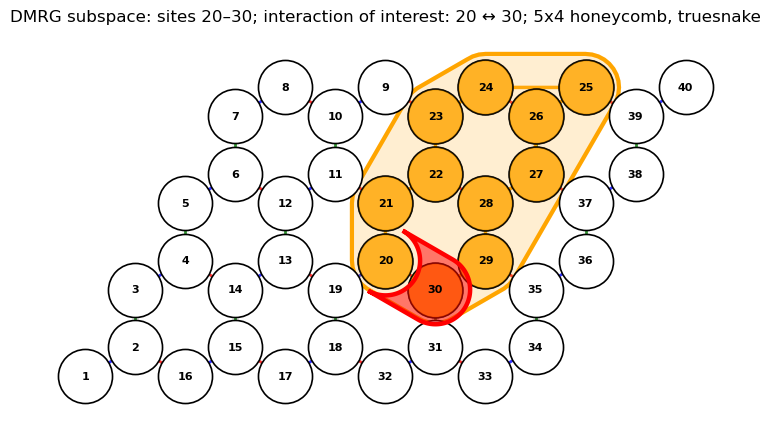

: 

In [ ]:
# Przykład użycia
plot_current_lattice_subspace_with_connection(
    20,
    30,
    plot_type="truesnake",
    connection_radius_scale=0.60,
)
